# 03 — Supervised Learning: Regression (Preetham's Scikit-learn Mastery Series)

Part 3 of 5. Covers Linear Regression, Ridge, Lasso, ElasticNet, Decision Tree/Random Forest/Gradient Boosting regressors, and regression metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

housing = load_diabetes()
X, y = housing.data, housing.target
print('Shape:', X.shape)
print('Features:', housing.feature_names)
print('Target: Disease progression score one year after baseline')

Shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target: Disease progression score one year after baseline


## 1. Train/Test Split + Scaling

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (353, 10) | Test: (89, 10)


## 2. Linear Regression — The Baseline

In [3]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_preds = lr.predict(X_test_s)
print('R² Score:', round(r2_score(y_test, lr_preds), 4))
print('MAE     :', round(mean_absolute_error(y_test, lr_preds), 4))
print('RMSE    :', np.sqrt(mean_squared_error(y_test, lr_preds)).round(4))

R² Score: 0.4526
MAE     : 42.7941
RMSE    : 53.8534


## 3. Interpreting Linear Regression Coefficients

In [4]:
coef_df = pd.DataFrame({'feature': housing.feature_names, 'coefficient': lr.coef_}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

  feature  coefficient
4      s1   -44.448856
8      s5    35.161195
2     bmi    25.607121
5      s2    24.640954
3      bp    16.828872
7      s4    13.138784
1     sex   -11.511809
6      s3     7.676978
9      s6     2.351364
0     age     1.753758


## 4. Ridge Regression — L2 Regularization

In [5]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
ridge_preds = ridge.predict(X_test_s)
print('Ridge R²:', round(r2_score(y_test, ridge_preds), 4))

Ridge R²: 0.4541


## 5. Lasso Regression — L1 Regularization (Can Zero Out Features)

In [6]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_s, y_train)
lasso_preds = lasso.predict(X_test_s)
print('Lasso R²:', round(r2_score(y_test, lasso_preds), 4))
print('Zeroed-out coefficients:', (lasso.coef_ == 0).sum(), 'out of', len(lasso.coef_))

Lasso R²: 0.4529
Zeroed-out coefficients: 0 out of 10


## 6. ElasticNet — Combining Ridge and Lasso

In [7]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train_s, y_train)
elastic_preds = elastic.predict(X_test_s)
print('ElasticNet R²:', round(r2_score(y_test, elastic_preds), 4))

ElasticNet R²: 0.4549


## 7. Comparing Regularization Strength (alpha)

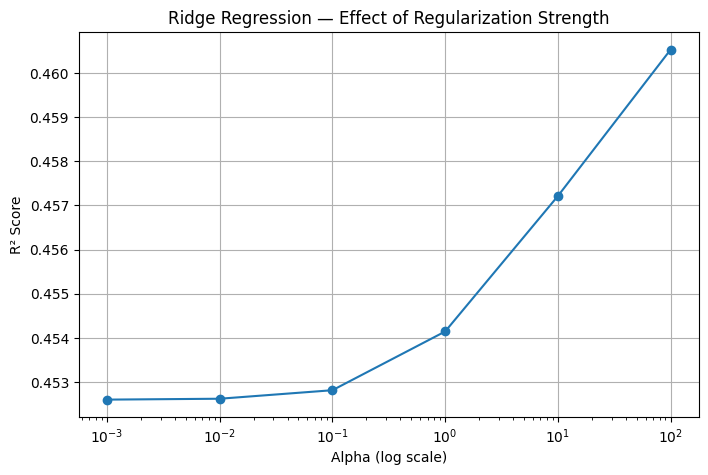

In [8]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_scores = []
for a in alphas:
    r = Ridge(alpha=a).fit(X_train_s, y_train)
    ridge_scores.append(r2_score(y_test, r.predict(X_test_s)))

plt.figure(figsize=(8, 5))
plt.plot(alphas, ridge_scores, marker='o')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.title('Ridge Regression — Effect of Regularization Strength')
plt.grid(True)
plt.show()

## 8. Decision Tree Regressor

In [9]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_reg.fit(X_train, y_train)
tree_preds = tree_reg.predict(X_test)
print('Decision Tree R²:', round(r2_score(y_test, tree_preds), 4))

Decision Tree R²: 0.2785


## 9. Random Forest Regressor

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
rf_preds = rf_reg.predict(X_test)
print('Random Forest R²:', round(r2_score(y_test, rf_preds), 4))
print('Random Forest MAE:', round(mean_absolute_error(y_test, rf_preds), 4))

Random Forest R²: 0.4428
Random Forest MAE: 44.053


## 10. Gradient Boosting Regressor

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, random_state=42)
gb_reg.fit(X_train, y_train)
gb_preds = gb_reg.predict(X_test)
print('Gradient Boosting R²:', round(r2_score(y_test, gb_preds), 4))

Gradient Boosting R²: 0.4514


## 11. Comparing All Regression Models

               Model        R2
3         ElasticNet  0.454897
1              Ridge  0.454147
2              Lasso  0.452947
0             Linear  0.452603
6  Gradient Boosting  0.451448
5      Random Forest  0.442823
4      Decision Tree  0.278494


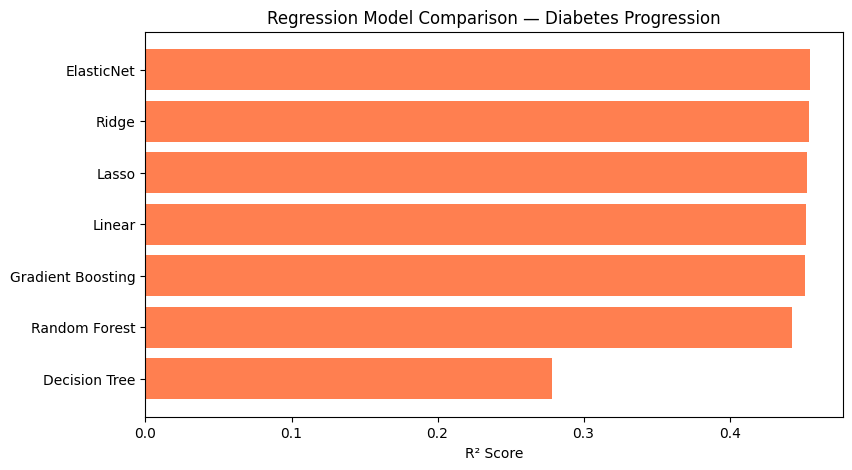

In [12]:
results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'R2': [
        r2_score(y_test, lr_preds), r2_score(y_test, ridge_preds), r2_score(y_test, lasso_preds),
        r2_score(y_test, elastic_preds), r2_score(y_test, tree_preds), r2_score(y_test, rf_preds), r2_score(y_test, gb_preds)
    ]
}).sort_values('R2', ascending=False)
print(results)

plt.figure(figsize=(9, 5))
plt.barh(results['Model'], results['R2'], color='coral')
plt.xlabel('R² Score')
plt.title('Regression Model Comparison — Diabetes Progression')
plt.gca().invert_yaxis()
plt.show()

## 12. Predicted vs Actual — Best Model

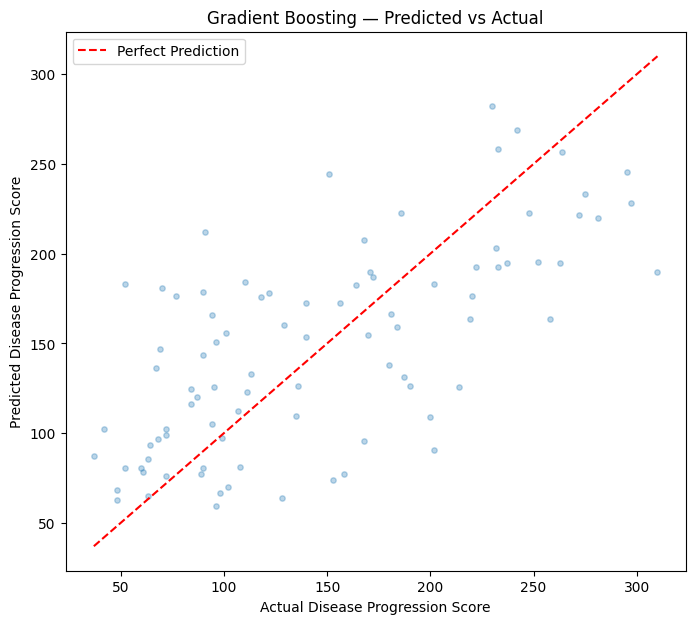

In [13]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, gb_preds, alpha=0.3, s=15)
lims = [min(y_test.min(), gb_preds.min()), max(y_test.max(), gb_preds.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Disease Progression Score')
plt.ylabel('Predicted Disease Progression Score')
plt.title('Gradient Boosting — Predicted vs Actual')
plt.legend()
plt.show()

## 13. Residual Plot — Checking for Patterns

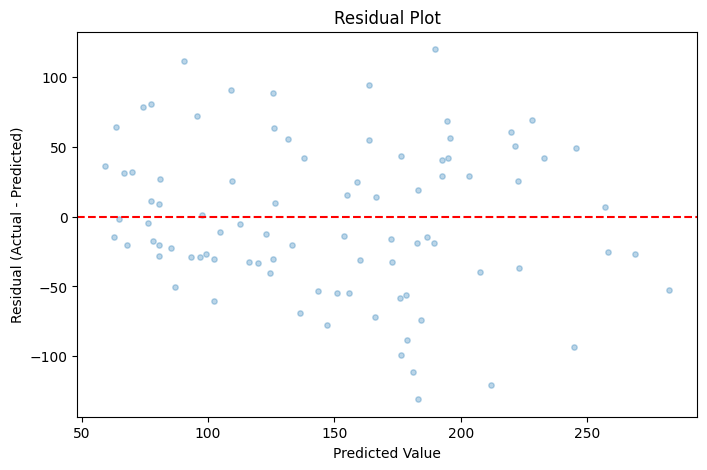

In [14]:
residuals = y_test - gb_preds
plt.figure(figsize=(8, 5))
plt.scatter(gb_preds, residuals, alpha=0.3, s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Value')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

## 14. Feature Importance for House Price Prediction

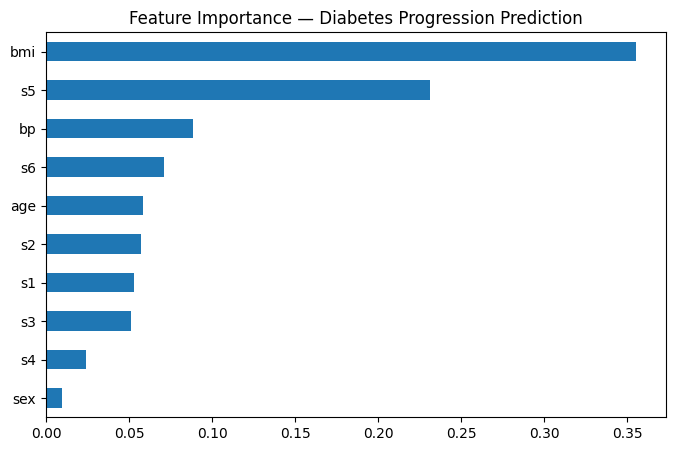

In [15]:
importances = pd.Series(rf_reg.feature_importances_, index=housing.feature_names).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title('Feature Importance — Diabetes Progression Prediction')
plt.gca().invert_yaxis()
plt.show()

## 15. Summary — What You Learned

| Model | Key Trait |
|---|---|
| Linear Regression | Simple baseline, interpretable coefficients |
| Ridge | L2 regularization — shrinks coefficients |
| Lasso | L1 regularization — can zero out features entirely |
| ElasticNet | Combines Ridge + Lasso |
| Decision Tree | Captures non-linear relationships |
| Random Forest | Strong general performer, less overfitting than single tree |
| Gradient Boosting | Usually the best performer on tabular regression |

Plus: R², MAE, RMSE, residual analysis, and regularization strength tuning.

### Next Notebook
Continue to **`04_unsupervised_preprocessing.ipynb`** for clustering, PCA, and advanced preprocessing.